# Projecct Aim

#### The aim of this project is to analyze mobile phone specifications and predict the price range of mobile phones using Machine Learning techniques.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
dataset = pd.read_csv('Cellphoneprice.csv')
dataset.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0,1


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [6]:
dataset.isnull().sum()  

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [7]:
dataset.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,9.916500,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,6.064315,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,0.000000,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,5.000000,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,10.000000,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,15.000000,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,20.000000,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [8]:
dataset.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [9]:
dataset.duplicated().sum()

np.int64(0)

In [10]:
dataset.shape

(2000, 21)

# EDA

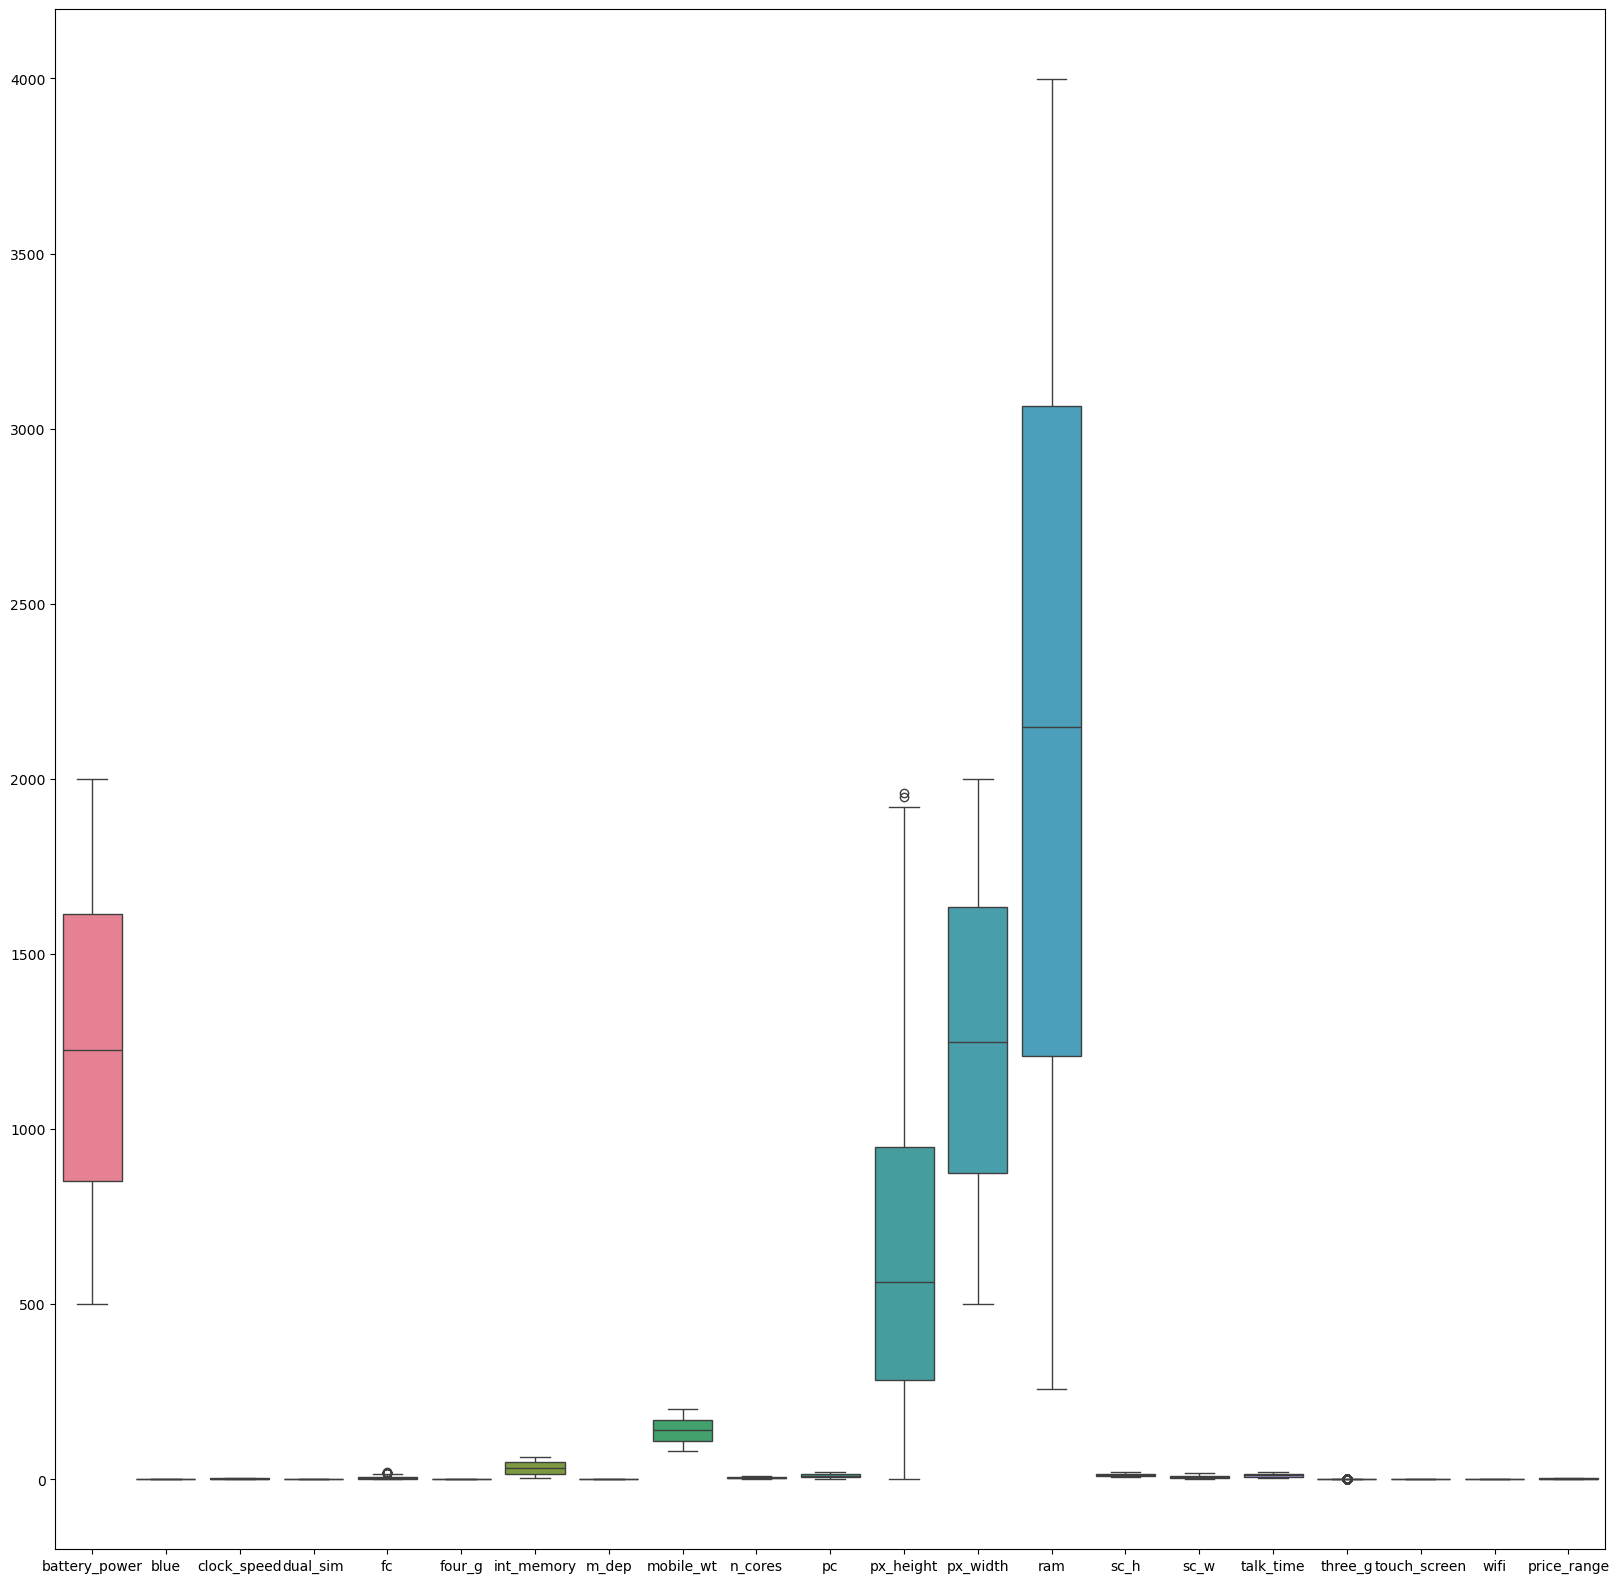

In [11]:
plt.figure(figsize=(20,20))
sns.boxplot(data=dataset)
plt.show()

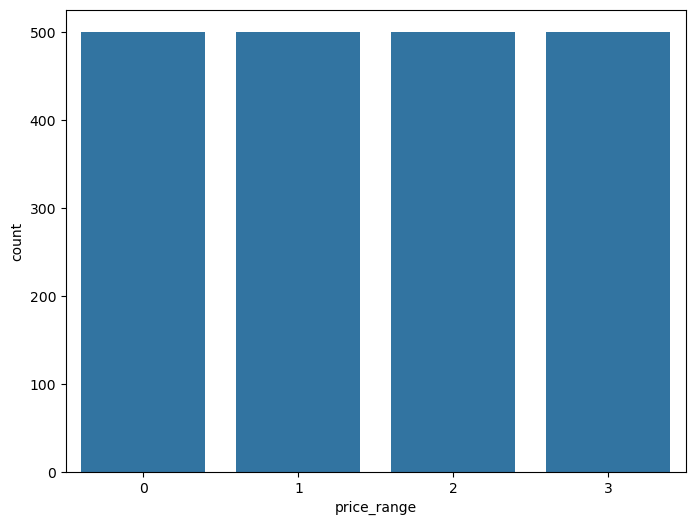

In [12]:
plt.figure(figsize=(8,6))
sns.countplot(x='price_range',data=dataset)
plt.show()

In [13]:
corr = dataset.corr()
corr

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
battery_power,1.000000,0.011252,0.011482,-0.041847,0.033334,0.015665,-0.004004,0.034085,0.001844,-0.029727,0.031441,0.014901,-0.008402,-0.000653,-0.029959,-0.021421,0.052510,0.011522,-0.010516,-0.008343,0.200723
blue,0.011252,1.000000,0.021419,0.035198,0.003593,0.013443,0.041177,0.004049,-0.008605,0.036161,-0.009952,-0.006872,-0.041533,0.026351,-0.002952,0.000613,0.013934,-0.030236,0.010061,-0.021863,0.020573
clock_speed,0.011482,0.021419,1.000000,-0.001315,-0.000434,-0.043073,0.006545,-0.014364,0.012350,-0.005724,-0.005245,-0.014523,-0.009476,0.003443,-0.029078,-0.007378,-0.011432,-0.046433,0.019756,-0.024471,-0.006606
dual_sim,-0.041847,0.035198,-0.001315,1.000000,-0.029123,0.003187,-0.015679,-0.022142,-0.008979,-0.024658,-0.017143,-0.020875,0.014291,0.041072,-0.011949,-0.016666,-0.039404,-0.014008,-0.017117,0.022740,0.017444
fc,0.033334,0.003593,-0.000434,-0.029123,1.000000,-0.016560,-0.029133,-0.001791,0.023618,-0.013356,0.644595,-0.009990,-0.005176,0.015099,-0.011014,-0.012373,-0.006829,0.001793,-0.014828,0.020085,0.021998
four_g,0.015665,0.013443,-0.043073,0.003187,-0.016560,1.000000,0.008690,-0.001823,-0.016537,-0.029706,-0.005598,-0.019236,0.007448,0.007313,0.027166,0.037005,-0.046628,0.584246,0.016758,-0.017620,0.014772
int_memory,-0.004004,0.041177,0.006545,-0.015679,-0.029133,0.008690,1.000000,0.006886,-0.034214,-0.028310,-0.033273,0.010441,-0.008335,0.032813,0.037771,0.011731,-0.002790,-0.009366,-0.026999,0.006993,0.044435
m_dep,0.034085,0.004049,-0.014364,-0.022142,-0.001791,-0.001823,0.006886,1.000000,0.021756,-0.003504,0.026282,0.025263,0.023566,-0.009434,-0.025348,-0.018388,0.017003,-0.012065,-0.002638,-0.028353,0.000853
mobile_wt,0.001844,-0.008605,0.012350,-0.008979,0.023618,-0.016537,-0.034214,0.021756,1.000000,-0.018989,0.018844,0.000939,0.000090,-0.002581,-0.033855,-0.020761,0.006209,0.001551,-0.014368,-0.000409,-0.030302
n_cores,-0.029727,0.036161,-0.005724,-0.024658,-0.013356,-0.029706,-0.028310,-0.003504,-0.018989,1.000000,-0.001193,-0.006872,0.024480,0.004868,-0.000315,0.025826,0.013148,-0.014733,0.023774,-0.009964,0.004399


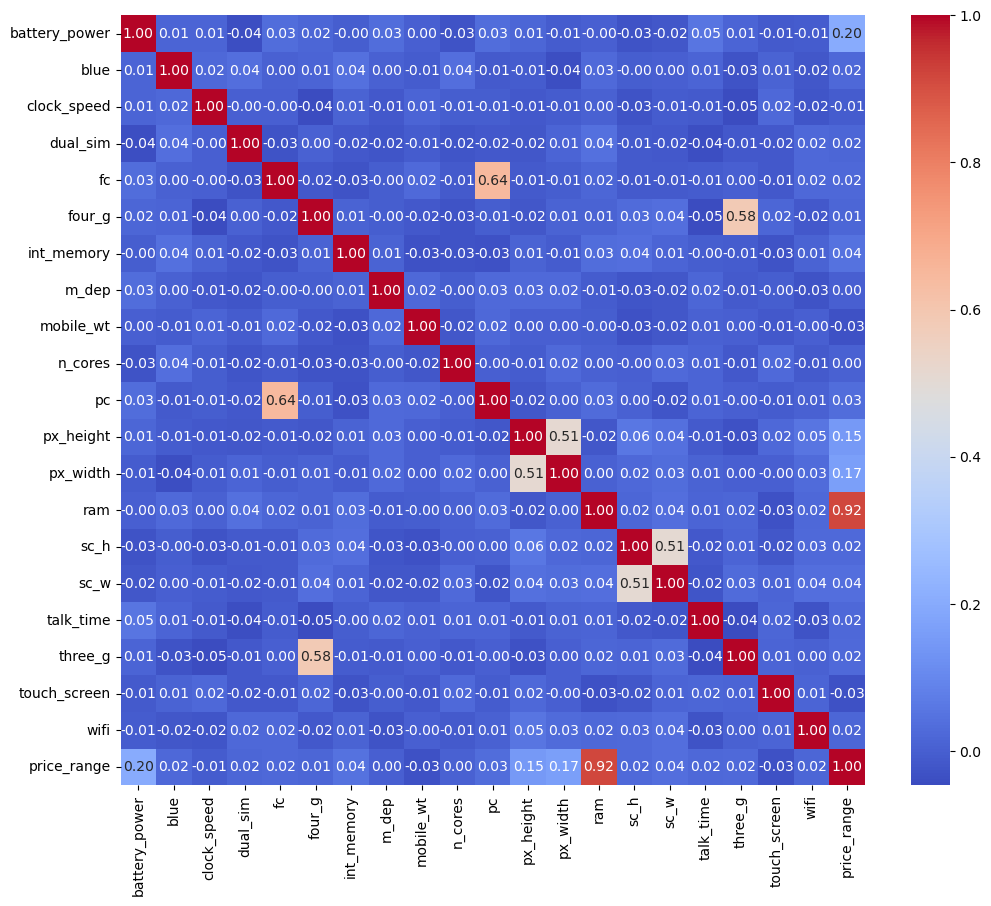

In [14]:
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

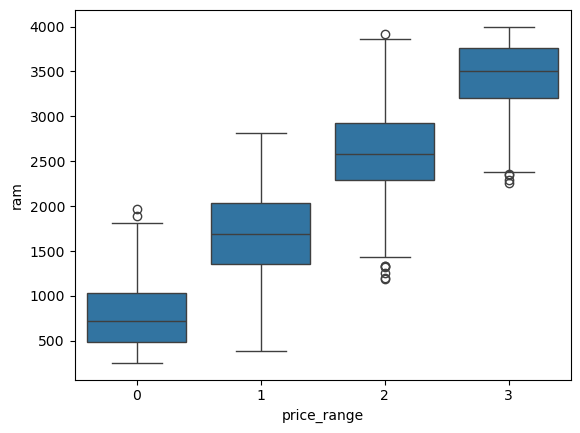

In [15]:

sns.boxplot(x='price_range',y='ram',data=dataset)
plt.show()

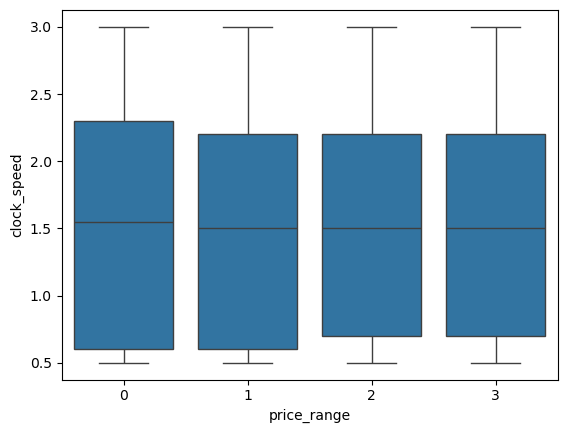

In [16]:
sns.boxplot(x='price_range',y='clock_speed',data=dataset)
plt.show()

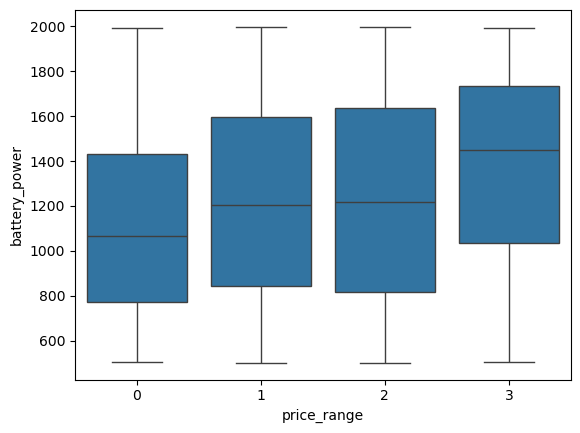

In [17]:
sns.boxplot(x='price_range',y='battery_power',data=dataset)
plt.show()

In [18]:
# Data preprocessing
x = dataset.drop('price_range',axis=1)
y = dataset['price_range']

# train and test split


In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1600, 20)
(400, 20)
(1600,)
(400,)


In [21]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)
print(x_train)
print(x_test)

[[ 1.54835969 -0.98142253 -1.23622976 ...  0.55713671  0.9900495
   1.00250313]
 [-1.3795348   1.01892912  0.83711156 ...  0.55713671  0.9900495
   1.00250313]
 [-0.01091435 -0.98142253 -0.74838475 ...  0.55713671 -1.0100505
   1.00250313]
 ...
 [ 1.33500924  1.01892912 -1.23622976 ...  0.55713671 -1.0100505
   1.00250313]
 [ 1.55743843 -0.98142253 -0.74838475 ... -1.79489161  0.9900495
   1.00250313]
 [-1.37499543  1.01892912 -1.11426851 ...  0.55713671 -1.0100505
  -0.99750312]]
[[ 0.91965677 -0.98142253  1.20299532 ...  0.55713671  0.9900495
  -0.99750312]
 [-0.13347738 -0.98142253 -1.23622976 ...  0.55713671 -1.0100505
  -0.99750312]
 [ 1.65957429 -0.98142253  1.69084034 ...  0.55713671  0.9900495
  -0.99750312]
 ...
 [-0.446694   -0.98142253  0.34926654 ...  0.55713671  0.9900495
   1.00250313]
 [-1.16391466 -0.98142253  1.44691783 ...  0.55713671  0.9900495
   1.00250313]
 [-0.12666832 -0.98142253  0.4712278  ...  0.55713671  0.9900495
   1.00250313]]


## logistic regression

In [22]:
# logistic regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [23]:
y_pred = lr.predict(x_test)
print(y_pred)

[0 2 1 3 1 1 2 0 3 1 0 1 2 3 3 2 3 3 1 0 0 2 1 2 0 1 3 2 2 0 0 0 3 0 1 1 2
 0 3 0 2 3 2 0 2 2 2 1 3 1 3 1 0 0 1 1 1 3 0 0 1 3 3 1 0 0 3 3 1 2 2 2 0 1
 2 0 1 3 2 2 3 2 1 0 1 3 1 3 3 0 3 3 2 1 3 2 2 3 1 1 0 0 1 0 0 3 2 0 1 1 0
 0 3 1 3 2 3 2 0 2 1 3 2 1 3 3 0 2 0 2 3 0 2 2 0 3 1 0 0 2 3 1 3 2 0 0 0 1
 1 2 3 1 1 0 2 2 0 1 0 2 2 3 3 3 1 0 1 2 2 3 3 0 1 0 3 1 1 2 1 0 0 0 0 0 3
 2 0 3 0 0 0 0 1 3 3 1 0 1 1 1 1 2 2 3 3 3 1 2 0 0 0 2 1 1 3 1 0 2 1 1 3 2
 3 0 0 2 1 3 0 1 2 0 2 3 2 0 1 3 3 0 1 3 2 3 0 3 1 2 3 3 2 1 1 3 3 1 3 3 3
 3 3 0 1 2 2 2 3 0 2 3 2 2 2 1 0 2 0 3 3 1 3 1 1 3 1 2 0 0 3 0 1 2 3 3 3 1
 1 0 1 3 3 0 1 2 2 0 3 3 2 3 2 3 2 0 2 1 1 1 0 0 0 3 3 3 1 0 1 0 1 2 3 0 3
 3 2 1 3 0 0 3 1 3 2 0 1 1 1 1 1 3 1 0 0 3 3 0 3 0 0 2 0 1 2 2 2 3 0 3 2 3
 3 3 3 2 1 1 0 3 1 3 3 0 2 3 2 3 3 3 0 0 2 3 0 0 2 3 2 1 1 2]


In [24]:
from sklearn.metrics import accuracy_score
lr_acc = accuracy_score(y_test,y_pred)
print(lr_acc)

0.975


In [25]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[101   4   0   0]
 [  0  91   0   0]
 [  0   2  87   3]
 [  0   0   1 111]]


In [26]:
from sklearn.metrics import classification_report
cr = classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       105
           1       0.94      1.00      0.97        91
           2       0.99      0.95      0.97        92
           3       0.97      0.99      0.98       112

    accuracy                           0.97       400
   macro avg       0.98      0.97      0.97       400
weighted avg       0.98      0.97      0.98       400



## Decision Tree

In [27]:
#decision tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [39]:
dt_pred = dt.predict(x_test)
print(dt_pred)

[0 2 1 3 1 1 2 0 2 1 0 1 1 3 2 2 3 3 1 0 0 1 1 2 0 1 2 2 2 0 1 0 3 0 1 1 2
 1 3 0 2 3 2 0 2 2 1 1 3 1 3 1 0 0 0 0 1 3 0 0 1 3 3 1 0 0 3 3 1 2 2 2 0 1
 3 0 0 3 2 2 3 2 1 0 1 3 2 3 3 0 3 3 2 1 3 2 2 3 1 1 0 0 1 0 0 3 2 0 1 1 0
 0 2 1 2 2 3 2 0 2 1 3 2 1 3 3 0 3 1 2 3 0 2 2 0 3 1 0 0 2 3 1 3 3 0 0 0 1
 2 3 3 1 1 0 2 2 0 1 0 1 2 3 3 3 1 0 1 2 2 3 3 1 1 0 3 1 1 2 1 0 0 0 0 0 3
 3 0 3 0 1 0 0 1 3 3 1 0 1 1 1 1 1 2 2 3 3 1 2 0 0 0 2 1 1 3 1 1 3 1 1 3 1
 3 0 0 1 1 3 0 1 2 0 2 3 2 0 1 3 3 0 2 3 3 3 0 3 1 2 3 3 2 0 0 3 3 0 3 3 3
 3 3 0 1 2 2 1 2 0 2 3 2 3 2 1 0 2 0 2 3 1 3 1 0 3 1 2 0 0 3 0 1 3 3 3 3 0
 1 0 1 3 3 0 1 2 2 0 3 3 2 3 1 3 2 0 2 1 1 1 0 0 1 3 3 3 1 0 1 1 2 3 3 1 3
 3 2 1 3 0 0 3 1 3 3 0 1 1 1 0 2 3 1 0 0 3 3 0 3 0 0 2 0 1 2 2 2 3 1 2 2 2
 3 3 3 3 1 1 0 3 2 3 3 0 2 3 2 3 3 3 1 0 2 3 0 0 2 3 1 1 1 2]


In [40]:
# evaluate the model

dt_accuracy = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy:", dt_accuracy)
cm_dt = confusion_matrix(y_test, dt_pred)
print("Confusion Matrix:\n", cm_dt)
cr_dt = classification_report(y_test, dt_pred)
print("Classification Report:\n", cr_dt)

Decision Tree Accuracy: 0.85
Confusion Matrix:
 [[ 93  12   0   0]
 [  6  80   5   0]
 [  0  11  66  15]
 [  0   0  11 101]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.89      0.91       105
           1       0.78      0.88      0.82        91
           2       0.80      0.72      0.76        92
           3       0.87      0.90      0.89       112

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



## Random Forest

In [28]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train,y_train)

RandomForestClassifier()

In [29]:
rf_y_pred = rf.predict(x_test)
print(rf_y_pred)

[0 2 1 3 1 2 2 0 3 1 0 0 2 3 2 2 3 3 1 0 0 1 1 2 0 1 3 2 2 0 0 0 3 0 1 1 2
 0 3 0 2 3 2 0 3 2 1 1 3 1 3 1 0 0 1 1 1 2 0 0 0 3 3 1 0 0 3 3 1 2 2 2 0 1
 2 0 0 3 2 2 3 2 1 0 1 3 1 3 3 0 3 3 2 1 3 2 2 3 2 1 0 0 1 0 0 3 2 0 1 1 0
 0 3 1 3 2 3 2 0 2 1 3 2 1 3 3 0 3 0 2 3 0 2 2 0 3 1 0 0 2 3 0 2 2 0 0 0 1
 1 2 3 1 1 0 2 2 0 2 0 1 2 3 3 2 1 0 0 2 2 3 3 1 1 0 3 1 2 2 1 0 0 0 0 0 3
 2 0 3 0 0 0 0 1 3 3 1 0 1 2 1 1 2 2 2 3 3 1 2 0 0 0 2 1 1 3 1 0 2 1 1 3 1
 3 0 0 2 1 2 0 0 1 0 2 3 2 1 1 2 3 0 1 3 2 3 0 3 1 2 3 3 3 1 1 3 3 1 3 3 3
 3 3 0 1 2 2 2 2 0 2 3 2 2 2 1 0 1 0 2 3 1 3 1 0 3 1 2 0 0 3 0 1 2 3 3 3 1
 1 0 1 3 3 0 1 1 2 0 3 3 2 3 1 3 2 0 2 1 2 1 0 0 0 3 2 3 1 0 1 0 2 2 2 0 3
 3 2 1 3 0 0 3 1 3 2 0 1 1 2 1 1 3 1 0 0 3 3 0 3 0 0 2 0 0 2 2 2 3 0 3 2 2
 3 3 3 2 1 2 0 3 1 3 3 0 2 3 2 3 3 3 0 0 2 3 0 0 2 3 2 1 1 2]


In [30]:
rf_acc = accuracy_score(y_test,rf_y_pred)
print(rf_acc)

0.89


In [31]:
rf_cm = confusion_matrix(y_test,rf_y_pred)
rf_cm

array([[101,   4,   0,   0],
       [  6,  77,   8,   0],
       [  0,   9,  78,   5],
       [  0,   0,  12, 100]])

In [32]:
print(classification_report(y_test,rf_y_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       105
           1       0.86      0.85      0.85        91
           2       0.80      0.85      0.82        92
           3       0.95      0.89      0.92       112

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400



## xgboost classifier

In [33]:
# xgboost classifier
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [34]:
xgb_pred = xgb.predict(x_test)
print(xgb_pred)

[0 2 1 3 1 1 2 0 3 1 0 1 2 3 2 2 3 3 1 0 0 1 1 2 0 1 3 2 2 0 0 0 3 0 1 1 2
 0 3 0 2 3 2 0 3 2 1 1 3 1 3 1 0 0 1 1 1 2 0 0 1 3 3 1 0 0 3 3 1 2 2 2 0 1
 2 0 0 3 2 2 3 2 1 0 1 3 1 3 3 0 3 3 2 1 3 2 2 3 2 1 0 0 1 0 0 3 2 0 1 1 0
 0 3 1 2 2 3 2 0 2 1 3 2 1 3 3 0 3 0 2 3 0 2 2 0 3 1 0 0 2 3 0 2 2 0 0 0 1
 1 2 3 1 1 0 2 2 0 1 0 1 2 3 2 2 1 0 0 2 2 3 3 1 1 0 3 1 1 2 1 0 0 0 0 0 3
 2 0 3 0 0 0 0 1 3 3 1 0 1 1 1 1 1 2 2 3 3 1 2 0 0 0 2 1 1 3 1 0 2 1 1 3 2
 3 0 0 2 1 2 0 1 2 0 2 3 2 1 1 3 3 0 1 3 3 3 0 3 1 2 3 3 2 1 1 3 3 1 3 3 3
 3 3 0 1 2 2 2 2 0 1 3 2 2 2 1 0 1 0 2 3 1 3 1 0 3 1 2 0 0 3 0 1 2 3 3 3 1
 1 0 1 3 3 0 1 1 2 0 3 3 2 3 2 3 2 0 2 1 1 1 0 0 0 3 2 3 1 0 1 0 1 3 3 0 2
 3 2 1 3 0 0 3 1 3 2 0 1 1 1 1 1 3 2 0 0 3 3 0 3 0 0 2 0 1 2 2 2 3 0 2 2 2
 3 3 3 2 1 2 0 3 1 3 3 0 2 3 2 3 3 3 0 0 2 3 0 0 2 3 2 1 1 2]


In [35]:
xgb_acc = accuracy_score(y_test,xgb_pred)
print(xgb_acc)

0.905


In [36]:
xgb_cm = confusion_matrix(y_test,xgb_pred)
xgb_cm

array([[100,   5,   0,   0],
       [  3,  86,   2,   0],
       [  0,   8,  78,   6],
       [  0,   0,  14,  98]])

In [37]:
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       105
           1       0.87      0.95      0.91        91
           2       0.83      0.85      0.84        92
           3       0.94      0.88      0.91       112

    accuracy                           0.91       400
   macro avg       0.90      0.91      0.90       400
weighted avg       0.91      0.91      0.91       400



## Model Comparison

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest','Xgboost'],
    'Accuracy': [lr_acc, dt_accuracy, rf_acc, xgb_acc]
})
comparison

,Model,Accuracy
0,Logistic Regression,0.975
1,Decision Tree,0.850
2,Random Forest,0.890
3,Xgboost,0.905


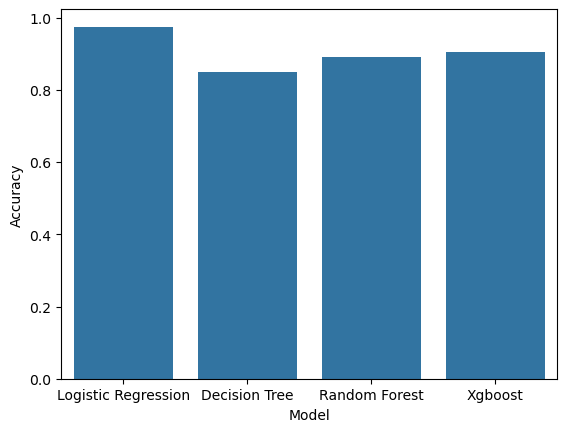

In [ ]:
sns.barplot(x='Model',y='Accuracy',data=comparison)
plt.show()

## FEATURE IMPORTANCE OF LOGISTICE REGRESSION 

In [ ]:
importance_lr = np.mean(abs(lr.coef_), axis=0)
feature_importance = pd.DataFrame({'Features': x.columns,'Importance':importance_lr})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

         Features  Importance
13            ram    7.167335
0   battery_power    1.824644
11      px_height    1.047964
12       px_width    1.038004
8       mobile_wt    0.284844
6      int_memory    0.124080
7           m_dep    0.092204
9         n_cores    0.081950
19           wifi    0.081056
14           sc_h    0.080174
3        dual_sim    0.071749
18   touch_screen    0.048208
15           sc_w    0.047811
17        three_g    0.047311
2     clock_speed    0.042461
5          four_g    0.041754
16      talk_time    0.040549
4              fc    0.034871
1            blue    0.026702
10             pc    0.022144


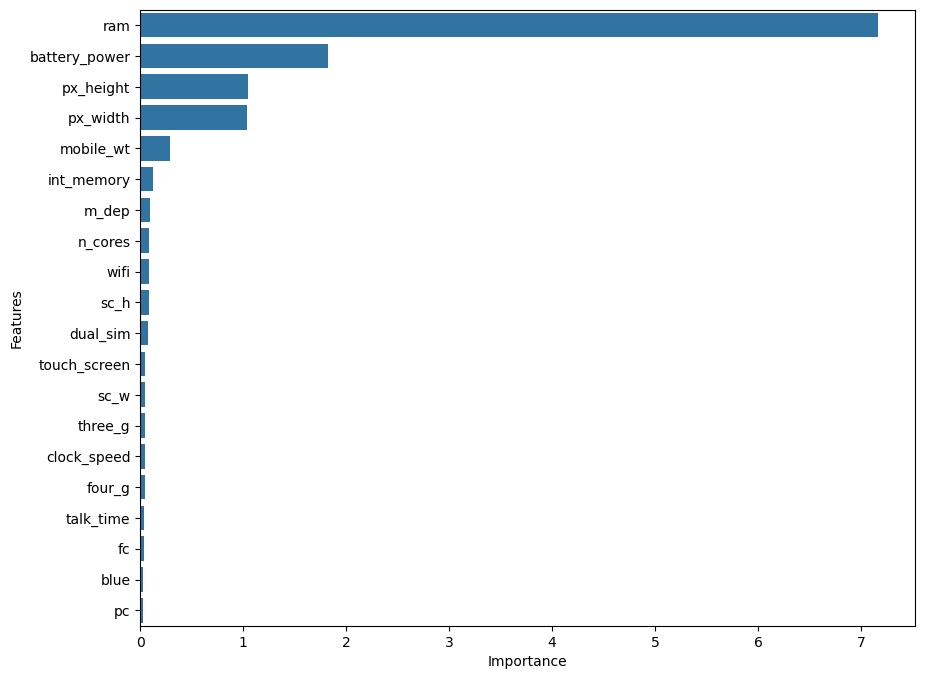

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(x='Importance',y='Features',data=feature_importance,)
plt.show()

In [43]:
# Sample prediction from test data
sample = x_test[0].reshape(1, -1)

In [ ]:
prediction_LR = lr.predict(sample)
print(prediction_LR)
if prediction_LR[0] == 0:
    print("The predicted price range is: Low")
elif prediction_LR[0] == 1:
    print("The predicted price range is: Medium")
elif prediction_LR[0] == 2:
    print("The predicted price range is: High")
else:    
    print("The predicted price range is: Very High")

[0]
The predicted price range is: Low


## Conclusion

In [ ]:
"""In this project, multiple Machine Learning classification models were trained and evaluated to predict mobile phone price ranges based on mobile specifications.

The following models were used:

Logistic Regression
Decision Tree
Random Forest
XGBoost

After comparing model performances:

Model	Accuracy
Logistic Regression	97.5%
Decision Tree	85%
Random Forest	89%
XGBoost	90.5%

Logistic Regression achieved the highest accuracy of 97.5%, making it the best-performing model for this dataset."""